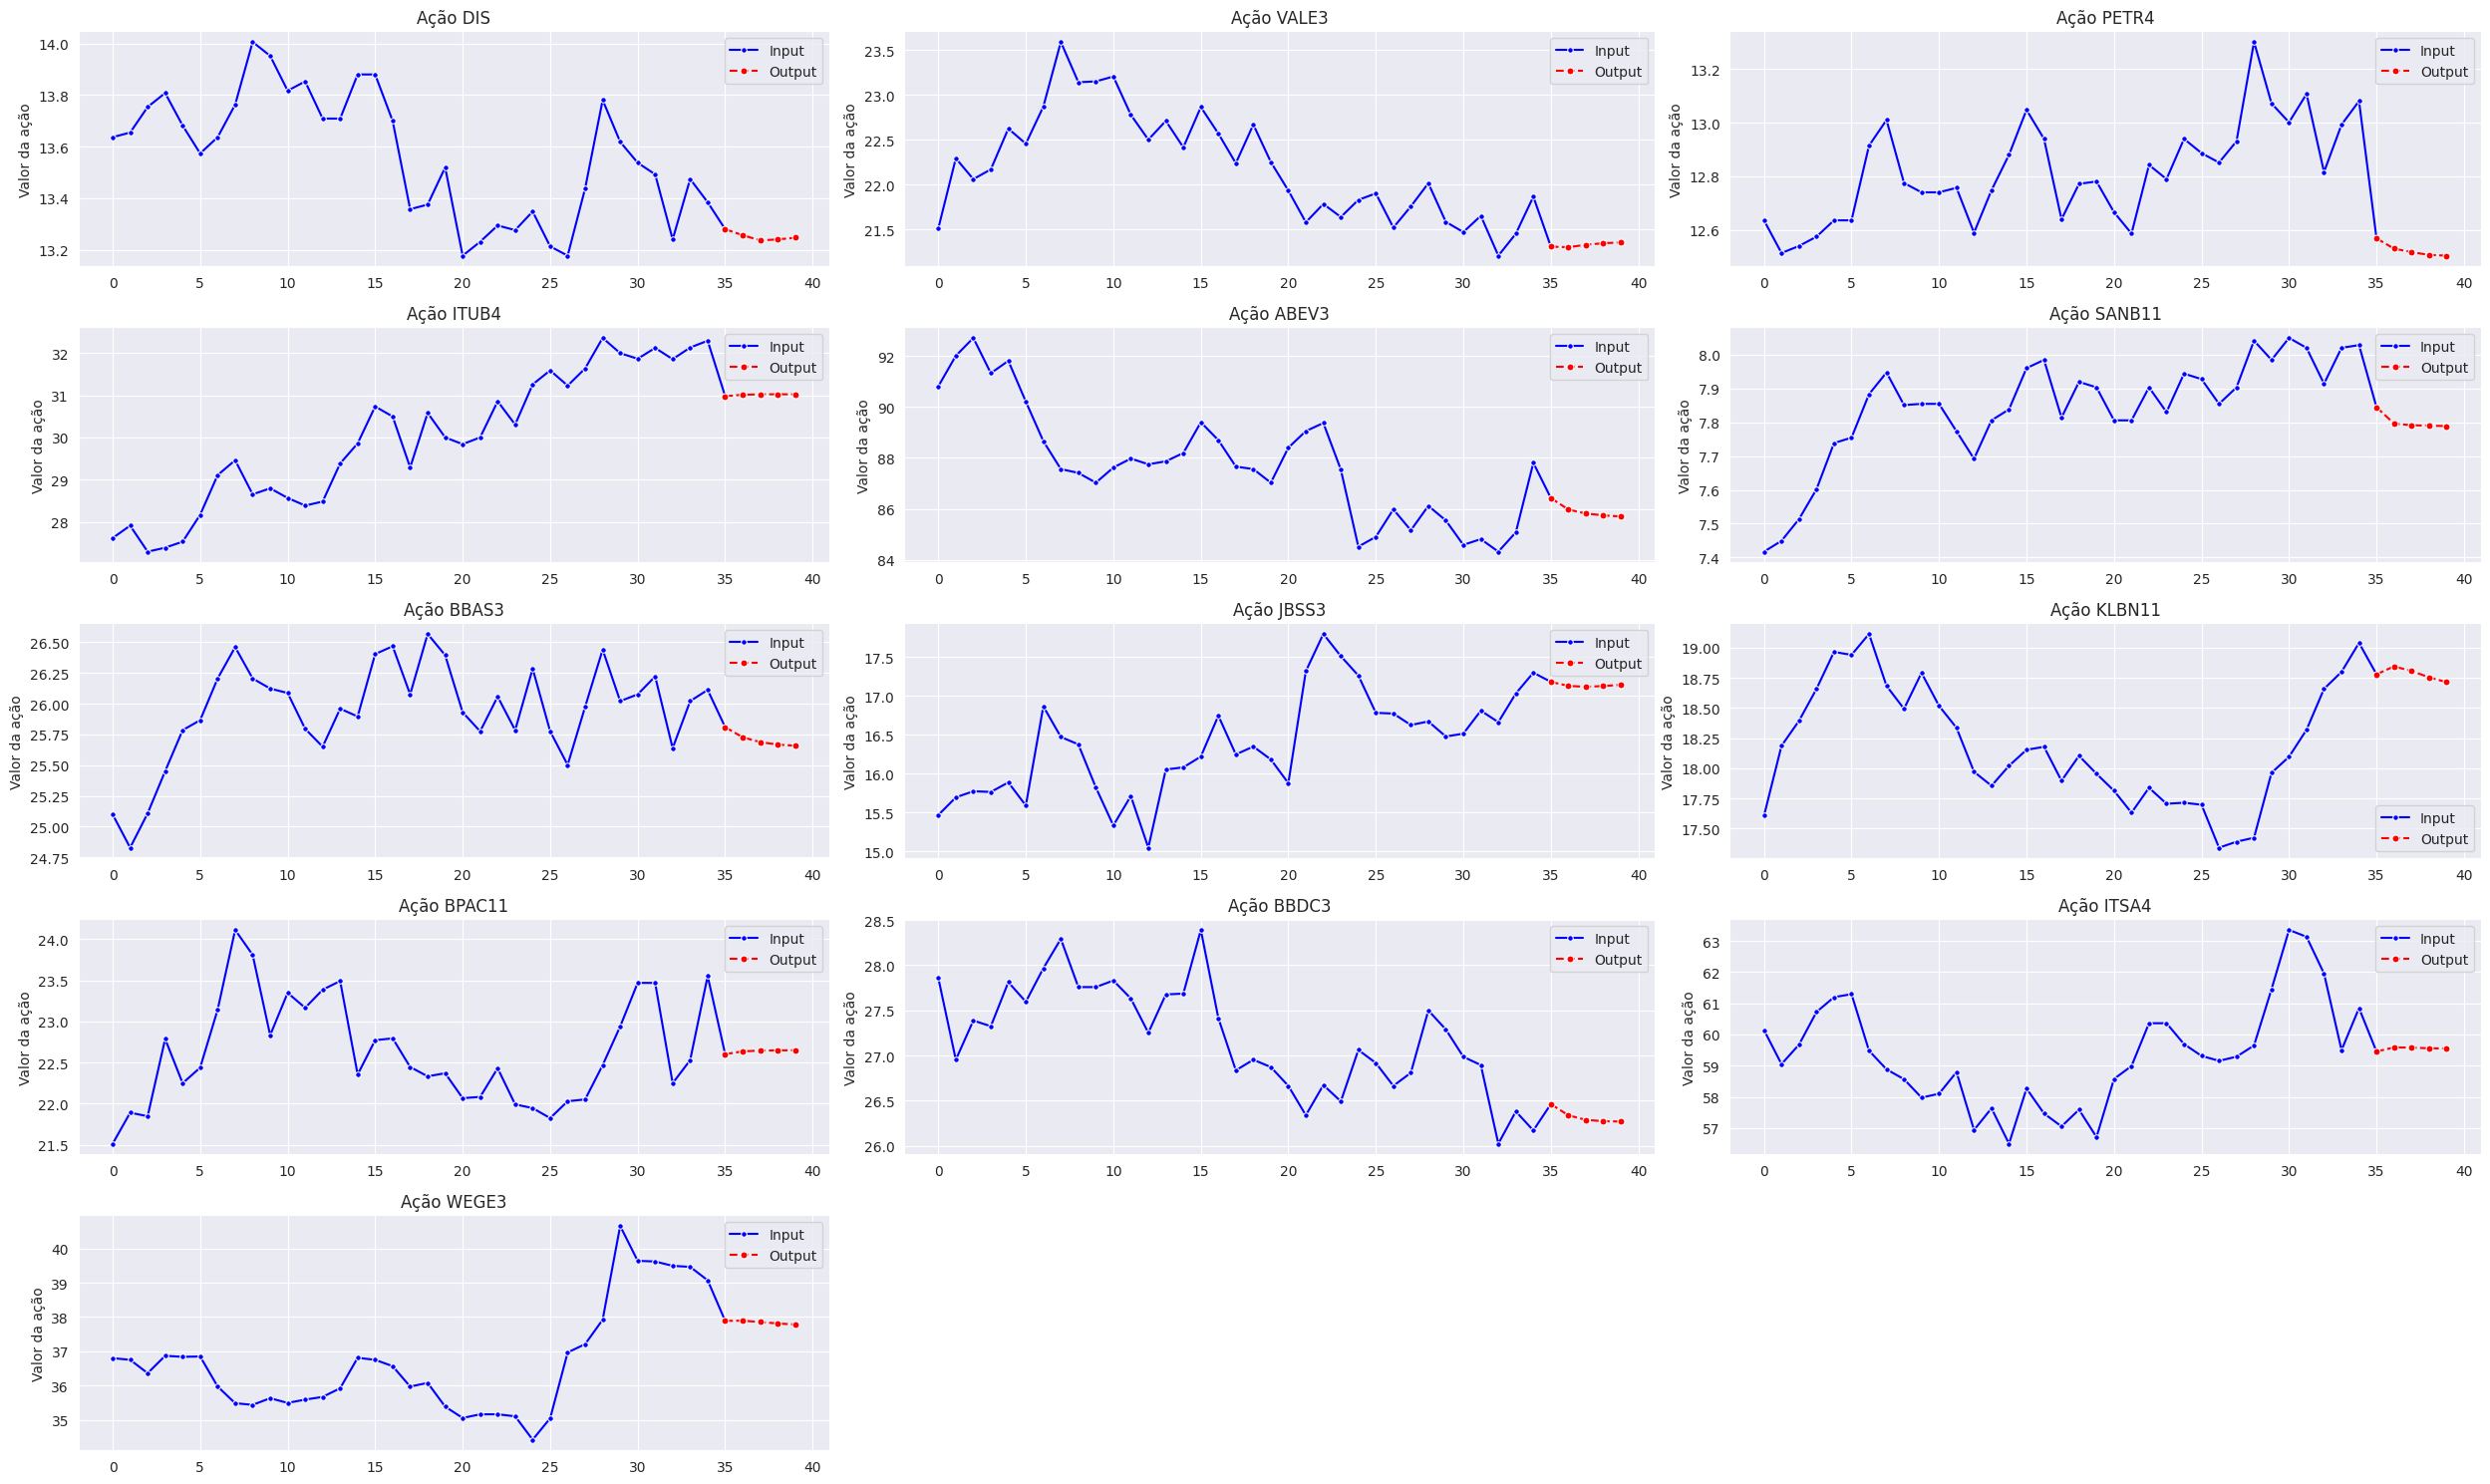

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from pathlib import Path

import numpy as np
import requests
import torch
from common.utils import get_path_project

# =============================================================================
# DADOS
# =============================================================================

# Garantindo os paths corretos
DIR_PROJECT = get_path_project()
assert isinstance(DIR_PROJECT, Path)

STAGED = DIR_PROJECT / "data/staged"

dataset_path = STAGED / "model_training/custom_dataset.pth"
dataset = torch.load(f=dataset_path, weights_only=False)

indice_amostra = np.random.randint(low=0, high=dataset.__len__())
X_exemplo, y_exemplo = dataset.__getitem__(idx=indice_amostra)
abc = X_exemplo.cpu().detach().numpy()

url = "http://127.0.0.1:8000/predict"

payload = json.dumps(
    {
        "series": abc.tolist()
    }
)
headers = {"Content-Type": "application/json"}

response = requests.request("POST", url, headers=headers, data=payload)

# =============================================================================
# VISUALIZANDO OS RESULTADOS
# =============================================================================

df = pd.concat([pd.DataFrame(X_exemplo), pd.DataFrame(y_exemplo)])
df["nature"] = "true"

y_pred = response.json()["prediction"]

df_pred = pd.DataFrame(y_pred)
df_pred["nature"] = "pred"

mixed_df = pd.concat([df, df_pred]).reset_index(drop=True)

in_len = 30
out_len = 5
total_len = in_len + out_len

num_cols = 13

SYMBOLS = [
    "DIS",
    "VALE3",
    "PETR4",
    "ITUB4",
    "ABEV3",
    "SANB11",
    "BBAS3",
    "JBSS3",
    "KLBN11",
    "BPAC11",
    "BBDC3",
    "ITSA4",
    "WEGE3",
]

fig, axes = plt.subplots(5, 3, figsize=(25, 15))
axes = axes.flatten()

for col in range(num_cols):
    ax = axes[col]

    sns.lineplot(
        data=mixed_df.iloc[: total_len + 1, [col]],
        x=mixed_df.index[: total_len + 1],
        y=mixed_df.columns[col],
        linestyle="-",
        marker="o",
        markersize=4,
        errorbar=None,
        color="blue",
        ax=ax,
        label="Input",
    )

    sns.lineplot(
        data=mixed_df.iloc[total_len:, [col]],
        x=mixed_df.index[total_len:],
        y=mixed_df.columns[col],
        linestyle="--",
        marker="o",
        markersize=5,
        errorbar=None,
        color="red",
        ax=ax,
        label="Output",
    )

    ax.set_xlabel("")
    ax.set_ylabel("Valor da ação")

    ax.set_title(f"Ação {SYMBOLS[col]}")

    ax.legend()

for idx in range(num_cols, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()

plt.show()